In [1]:
!pip install torchmetrics
!pip install torchsummary
import os
import json
import random
from google.colab import drive,files
from IPython.display import clear_output
drive.mount('/content/drive')
clear_output()

In [ ]:
import numpy as np
import torch
from torchsummary import summary
from torchmetrics.classification import BinaryAccuracy
from torch import nn,optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import models
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import shutil # Для удаления папки
from wildFire_architecture import *
from Training_Wild_Fire_Models import *

In [3]:
shutil.rmtree('/content/drive/MyDrive/Wild_Fire_Proj')

In [ ]:
# создание словоря для json файла в котором хранится ключ kaggle
token = {'username':'...', 'key':'...'}

In [5]:
!mkdir -p ~/.kaggle
with open('/root/.kaggle/kaggle.json','w') as f:
  json.dump(token,f)

In [6]:
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset -q

Dataset URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset
License(s): other


In [8]:
!ls

drive  sample_data  wildfire-prediction-dataset.zip


In [9]:
# Распаковка архива
!unzip -q wildfire-prediction-dataset.zip -d dataset_folder

In [10]:
# Удаляется архивная папка
!rm wildfire-prediction-dataset.zip

In [11]:
train_dir = '/content/dataset_folder/train'
test_dir = '/content/dataset_folder/test'
valid_dir = '/content/dataset_folder/valid'

In [12]:
from PIL import Image,ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


def display_random_samples(dataset_dir):
  classes_all = os.listdir(dataset_dir)
  plt.figure(figsize=(15, 10))

  for i, class_name in enumerate(classes_all):
    class_dir = os.path.join(dataset_dir,class_name)
    imagen_files = os.listdir(class_dir)
    random_imag = random.choice(imagen_files)
    imge_path = os.path.join(class_dir,random_imag)
    image = Image.open(imge_path).convert('RGB')
    image_resize = image.resize((2000,2000))
    plt.subplot(1,len(classes_all), i+1)
    plt.imshow(image_resize)
    plt.axis('off')
    plt.title(f'{class_name},({image_resize.size[0]} x {image_resize.size[1]})')
  plt.show()

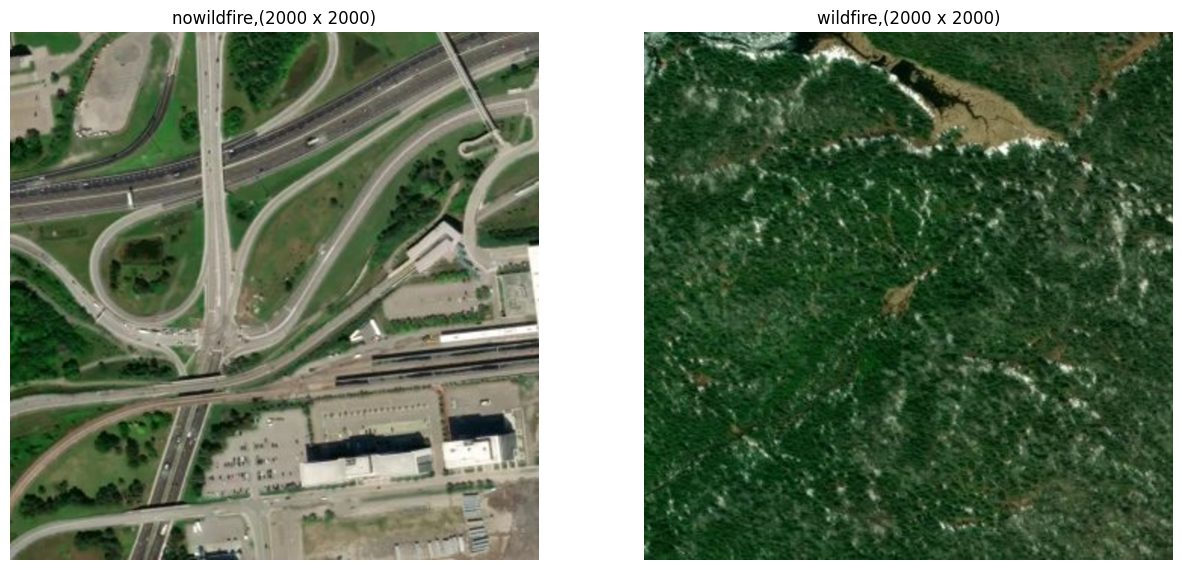

In [13]:
display_random_samples(valid_dir)

In [14]:
img_size = (224,224)
batch_size = 30

In [ ]:

transforms_train_resnet = transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.5,
                           saturation=0.6),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
resnet_train_data = datasets.ImageFolder(
    root = train_dir,
    transform = transforms_train_resnet
)
res_train_load = DataLoader(
    resnet_train_data,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2
)


In [ ]:
my_trainsform_train = transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.5,
                           saturation=0.6),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
train_data = datasets.ImageFolder(
    root = train_dir,
    transform = my_trainsform_train
)
train_loader = DataLoader(
    train_data,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2
)

In [ ]:
valid_test_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor()
])


valid_data = datasets.ImageFolder(
    root = valid_dir,
    transform = valid_test_transforms
)
valid_gen = DataLoader(
    valid_data,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 2
)

In [ ]:
test_data = datasets.ImageFolder(
    root = test_dir,
    transform = valid_test_transforms
)
test_gen = DataLoader(
    test_data,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 2
)

In [18]:
# Путь где будут хранится параметры сети
proj_path = '/content/drive/MyDrive/Wild_Fire_Proj'
if not os.path.exists(proj_path):
  os.makedirs(proj_path)

In [24]:
# урезанные данные для проверки тренировочного кода
ftn_model_subset_dtrain = Subset(train_data, indices=range(120))
ftn_model_subset_loader = DataLoader(
    ftn_model_subset_dtrain,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2
)
subset_data_train = Subset(my_data_train, indices=range(120))
subset_train_loader = DataLoader(
    subset_data_train,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2
)
subset_valid = Subset(valid_data, indices=range(60))
subset_valid_loader = DataLoader(
    subset_data_train,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2
)

In [ ]:
res50_params

In [ ]:
cnn_parmas

In [ ]:
my_res_params

# Новый раздел

In [36]:
#model.load_state_dict

In [ ]:
'''
  resnet50_train = Train_Model(name_model='Resnet50',path=proj_path,
                              epochs=3,train_data=ftn_model_subset_loader,
                              val_data=subset_valid_loader)
  resnet50_train(model=model_res50)'''

In [ ]:
resnet50_train = Train_Model(name_model='Resnet50',path=proj_path,
                              epochs=10,train_data=res_train_load,
                              val_data=valid_gen)
resnet50_train(model=model_res50)

In [ ]:
my_cnnr_train = Train_Model(name_model='My_CNNR',path=proj_path,
                              epochs=2,train_data=train_loader,
                              val_data=valid_gen)
my_cnnr_train(model=my_resmodel)

In [ ]:
my_cnn_train = Train_Model(name_model='My_CNN',path=proj_path,
                              epochs=10,train_data=train_loader,
                              val_data=valid_gen)
my_cnn_train(model=my_model_cnn)

In [ ]:
plot_accuracy(history_path='/content/drive/MyDrive/Wild_Fire_Proj/My_CNNR/accuhistory.json',
              name_model='My_CNNR')

In [ ]:
plot_accuracy(history_path='/content/drive/MyDrive/Wild_Fire_Proj/Resnet50/accuhistory.json',
              name_model='ResNet50')

In [ ]:
plot_accuracy(history_path='/content/drive/MyDrive/Wild_Fire_Proj/My_CNN/accuhistory.json',name_model='My_CNN')

In [ ]:
!ls '/content/drive/MyDrive/Wild_Fire_Proj/My_CNNR'

# Новый раздел

In [ ]:
model_dict = {'ResNet50':model_res50,'My_CNN':my_model}

In [ ]:
# Валидация
for key,val in model_dict.items():
  early_stopper = EarlyStopping(path=proj_path,name_model=key)
  model = val
  model.load_state_dict(torch.load(early_stopper.path), strict=False)
  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    progress_bar_valid = tqdm(valid_gen,desc=f'Valid {key}')
    for imagen,labels in progress_bar_valid:
      imagen,labels = imagen.to(device),labels.to(device)
      outputs = model(imagen)
      preds = (outputs > 0.5).float()
      total += labels.size(0)
      correct += (preds==total).sum().item()
    val_accuracy = 100*correct/total.round(4)

  print(f'{key} Valid Accuracy = {val_accuracy:.3f}%')

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
for name,model in model_dict.items():
  print(f'Generating confusion matrix for {name}')


In [ ]:
# Проверка модели на тестовых данных

model = best_model.load_state_dict(torch.load(results_valid['Params']))
model.eval()
with torch.no_grad():
  corect_test = 0
  total_test = 0
  for imagen,labels in test_gen:
    imagen,labels = imagen.to(device),labels.to(device)
    outputs = model(imagen)
    preds = (outputs>0.5).float
    total_test += labels.size(0)
    corect_test += (preds==total_test).sum().item()
  print(f'Test Accuracy {100*corect_test/total_test:.4f}%')
